In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm
from pymodulon.io import *
from pymodulon.compare import *
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import pickle


pd.set_option('display.max_columns', 100, 'display.max_rows', 100)

In [2]:
# Editing text on PDF:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
# read in ICA data object for P-MG and P-1K
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')
ica_p1k = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\precise-1-k-files\\p1k.json.gz')

## Figure 5A

In [4]:
links, dots = compare_ica(ica_data.M,ica_p1k.M, cutoff = 0.5)

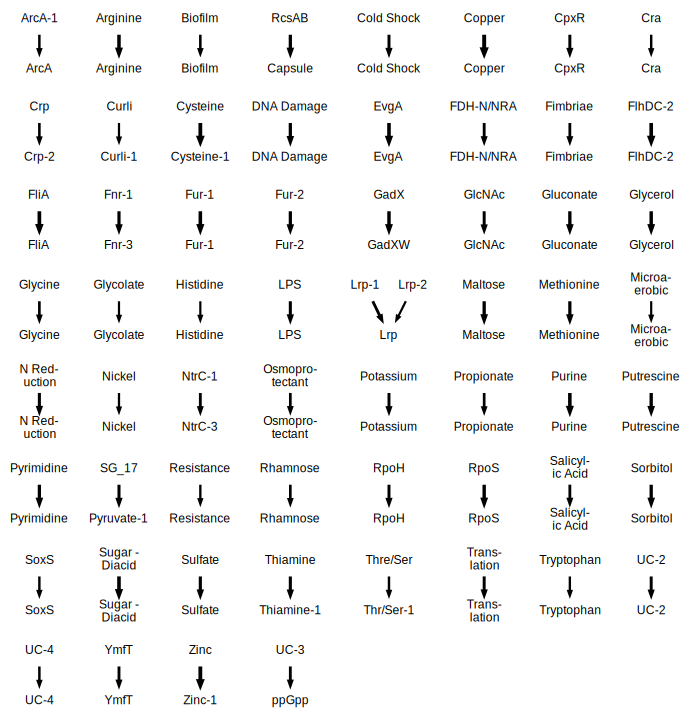

In [5]:
dots

In [6]:
# count of matched iMs in P-MG1655
matched_pmg_iMs = [el[0] for el in links]
print('P-MG1655 count: ', len(np.unique(matched_pmg_iMs)))
print('percentage: ', len(np.unique(matched_pmg_iMs))*100/ica_data.imodulon_table.shape[0])

P-MG1655 count:  61
percentage:  53.04347826086956


In [7]:
ica_data.imodulon_table.loc[np.unique(matched_pmg_iMs)].value_counts('functional_category')

functional_category
carbon metabolism           11
amino acid metabolism       10
envelope stress              6
extracellular structures     6
metal homeostasis            6
energy metabolism            5
unknown                      3
DNA damage                   2
nitrogen metabolism          2
nucleotide metabolism        2
redox stress                 2
temperature shock            2
cofactor metabolism          1
global stress                1
single_gene                  1
translation                  1
dtype: int64

In [8]:
ica_data.imodulon_table.value_counts('functional_category')

functional_category
single_gene                 23
carbon metabolism           17
amino acid metabolism       15
unknown                     12
energy metabolism            8
extracellular structures     8
envelope stress              7
metal homeostasis            6
nitrogen metabolism          3
nucleotide metabolism        3
cofactor metabolism          3
redox stress                 2
temperature shock            2
DNA damage                   2
global stress                1
formaldehyde metabolism      1
phosphate metabolism         1
translation                  1
dtype: int64

In [9]:
matched_p1k_iMs = [el[1] for el in links]
matched_p1k_iMs = np.unique(matched_p1k_iMs)

#iMs in p1k that do not have a match
ica_p1k.imodulon_table.loc[list(set(ica_p1k.imodulon_table.index.values).difference(set(matched_p1k_iMs)))].value_counts('system_category')

system_category
Metabolism             49
Stress Responses       24
Genetic Alterations    22
Single Gene            21
ALE Effects            13
Unknown                12
dtype: int64

In [10]:
set(ica_p1k.imodulon_table.index.values).difference(set(matched_p1k_iMs))

{'Acetate',
 'Acid Shock RNA',
 'BW25113',
 'BasR',
 'Biotin',
 'CCK-PGI Del',
 'CP4-44',
 'Cellulose',
 'Crp-1',
 'Curli-2',
 'Cysteine-2',
 'Cytochrome c',
 'DhaR',
 'Dipeptide',
 'Efflux Pump',
 'FDH-O',
 'FHL',
 'Fatty Acid',
 'Ferric Citrate',
 'Flagella',
 'FlhDC-1',
 'Fnr-1',
 'Fnr-2',
 'FucR/AllR/AraC',
 'FucR/ExuR',
 'GadX',
 'Galactose',
 'Glutamine',
 'Glutarate',
 'Glyoxylate',
 'Hot TALE 16',
 'IS Elements-1',
 'IS Elements-2',
 'IS1',
 'IS5',
 'Ile/Val',
 'Isc System',
 'Leu/Val/Ile',
 'Leucine',
 'Lysine/T2SS',
 'Magnesium',
 'Membrane',
 'Molybdenum',
 'NDH-1',
 'NO Stress',
 'NRZ',
 'Nickel/Cobalt',
 'Nitrate/Nitrite',
 'Nitrogen',
 'NrdR',
 'NtrC-1',
 'NtrC-2',
 'Nucleoside',
 'Nucleotide Stress',
 'Oxidoreductase',
 'OxyR',
 'PAL 10 Del',
 'PAL 26 Del',
 'PAL Amp',
 'PaaX',
 'Phage Shock',
 'Phosphate-1',
 'Phosphate-2',
 'PlaR',
 'Pyruvate-2',
 'Quorum Sensing',
 'ROS TALE Amp',
 'ROS TALE Del-1',
 'ROS TALE Del-2',
 'Ribose',
 'RpoE',
 'SCFA',
 'SSW SNPs',
 'Sialic

## Figure 5B-D

In [11]:
def compare_gene_weights(
    ica_data,
    imodulon1,
    imodulon2,
    ica_data2=None,
    ortho_file=None,
    use_org1_names=True,
    **kwargs,
):
    """
    Create a scatterplot comparing the gene weights between two iModulons

    Parameters
    ----------
    ica_data: ~pymodulon.core.IcaData
        :class:`~pymodulon.core.IcaData` object
    imodulon1 : int or str
        Name of `iModulon` on X-axis
    imodulon2 : int or str
        Name of `iModulon` on X-axis
    ica_data2: ~pymodulon.core.IcaData, optional
        :class:`~pymodulon.core.IcaData` object for second iModulon (if comparing
        iModulons across objects)
    ortho_file: str, optional
        Path to orthology file between organisms
    use_org1_names: bool
        If true, use gene names from first organism. If false, use gene names
        from second organism (default: True)
    **kwargs:
        Additional keyword arguments passed to :func:`pymodulon.plotting.scatterplot`

    Returns
    -------
    ax: ~matplotlib.axes.Axes
        :class:`~matplotlib.axes.Axes` containing the scatterplot
    """
    if ica_data2 is None:
        ica_data2 = ica_data.copy()

    M1, M2 = convert_gene_index(ica_data.M, ica_data2.M, ortho_file)
    bin_M1, bin_M2 = convert_gene_index(
        ica_data.M_binarized, ica_data2.M_binarized, ortho_file
    )

    # Convert gene table
    gene_table1, gene_table2 = convert_gene_index(
        ica_data.gene_table, ica_data2.gene_table, ortho_file, keep_locus=True
    )

    if use_org1_names:
        gene_table = gene_table1
        gene_table["locus_tag"] = gene_table.index
    else:
        gene_table = gene_table2

    x = M1[imodulon1]
    y = M2[imodulon2]

    xlabel = f"{imodulon1} Gene Weight"
    ylabel = f"{imodulon2} Gene Weight"

    # Override specific kwargs (their implementation is different
    # in this function)
    show_labels_cgw = kwargs.pop("show_labels", "auto")
    adjust_labels_cgw = kwargs.pop("adjust_labels", True)
    legend_cgw = kwargs.pop("legend", False)
    legend_kwargs_cgw = kwargs.pop("legend_kwargs", {})
    label_font_kwargs_cgw = kwargs.pop("label_font_kwargs", {})

    kwargs["show_labels"] = kwargs["adjust_labels"] = kwargs["legend"] = False
    kwargs["legend_kwargs"] = None

    # Remove xlabel and ylabel kwargs if provided
    kwargs.pop("xlabel", None)
    kwargs.pop("ylabel", None)

    # Scatter Plot
    ax = scatterplot(x, y, xlabel=xlabel, ylabel=ylabel, **kwargs)

    # Add thresholds to scatterplot (dashed lines)
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    thresh1 = ica_data.thresholds[imodulon1]
    thresh2 = ica_data2.thresholds[imodulon2]

    if thresh1 != 0:
        ax.vlines(
            [thresh1, -thresh1],
            ymin=ymin,
            ymax=ymax,
            colors="k",
            linestyles="dashed",
            linewidth=1,
        )

    if thresh2 != 0:
        ax.hlines(
            [thresh2, -thresh2],
            xmin=xmin,
            xmax=xmax,
            colors="k",
            linestyles="dashed",
            linewidth=1,
        )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Add labels on data-points
    component_genes_x = bin_M1[bin_M1[imodulon1] == 1].index
    component_genes_y = bin_M2[bin_M2[imodulon2] == 1].index
    
    # Identify unique genes for each imodulon
    unique_genes_x = bin_M1[bin_M1[imodulon1] == 1].index.difference(bin_M2[bin_M2[imodulon2] == 1].index)
    unique_genes_y = bin_M2[bin_M2[imodulon2] == 1].index.difference(bin_M1[bin_M1[imodulon1] == 1].index)
    
    # Plot the genes unique to imodulon1 (as blue)
    for gene in unique_genes_x:
        ax.scatter(M1.loc[gene, imodulon1], M2.loc[gene, imodulon2], color="pink")
        
    # Plot the genes unique to imodulon2 (as green)
    for gene in unique_genes_y:
        ax.scatter(M1.loc[gene, imodulon1], M2.loc[gene, imodulon2], color="orange")
    
    component_genes = component_genes_x.intersection(component_genes_y)
    texts = []
    expand_kwargs = {"expand_objects": (1.2, 1.4), "expand_points": (1.3, 1.3)}

    # Add labels: Put gene name if components contain under 20 genes
    auto = None
    if show_labels_cgw == "auto":
        auto = (
            bin_M1[imodulon1].astype(bool) & bin_M2[imodulon2].astype(bool)
        ).sum() <= 20

    if show_labels_cgw or auto:
        for gene in component_genes:
            ax.scatter(M1.loc[gene, imodulon1], M2.loc[gene, imodulon2], color="red")

            # Add labels
            text_kwargs = label_font_kwargs_cgw.copy()

            if "fontstyle" not in text_kwargs:
                text_kwargs.update({"fontstyle": "normal"})

            # Italicize gene if there is a defined name (not locus tag)
            try:
                gene_name = gene_table.loc[gene, "gene_name"]
                if gene_name != gene_table.loc[gene, "locus_tag"]:
                    text_kwargs.update({"fontstyle": "italic"})

            except KeyError:
                gene_name = gene

            # Set default fontsize
            if "fontsize" not in text_kwargs:
                text_kwargs.update({"fontsize": 12})

            texts.append(
                ax.text(
                    M1.loc[gene, imodulon1],
                    M2.loc[gene, imodulon2],
                    gene_name,
                    **text_kwargs,
                )
            )

        expand_kwargs["expand_text"] = (1.4, 1.4)

    # Add labels: Repel texts from other text and points
    rectx = ax.add_patch(
        Rectangle(
            xy=(xmin, -abs(thresh2)),
            width=xmax - xmin,
            height=2 * abs(thresh2),
            fill=False,
            linewidth=0,
        )
    )

    recty = ax.add_patch(
        Rectangle(
            xy=(-abs(thresh1), ymin),
            width=2 * abs(thresh1),
            height=ymax - ymin,
            fill=False,
            linewidth=0,
        )
    )

    if adjust_labels_cgw:
        adjust_text(
            texts=texts,
            add_objects=[rectx, recty],
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="k", lw=0.5),
            only_move={"objects": "y"},
            **expand_kwargs,
        )

    # Add legend
    if legend_cgw:
        ax.legend(**legend_kwargs_cgw)

    return ax

<AxesSubplot: xlabel='UC-4 Gene Weight', ylabel='UC-4 Gene Weight'>

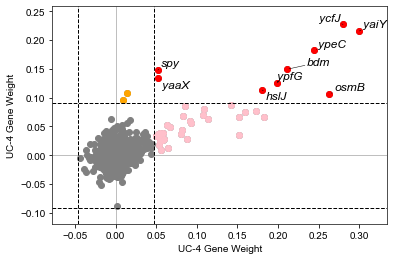

In [12]:
compare_gene_weights(ica_p1k, 'UC-4',
                 'UC-4', ica_data, colors = ['grey'])

<AxesSubplot: xlabel='Sugar Diacid Gene Weight', ylabel='Sugar Diacid Gene Weight'>

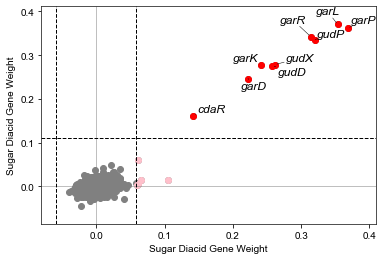

In [13]:
compare_gene_weights(ica_p1k, 'Sugar Diacid',
                    'Sugar Diacid', ica_data, colors = ['grey'])

<AxesSubplot: xlabel='SoxS Gene Weight', ylabel='SoxS Gene Weight'>

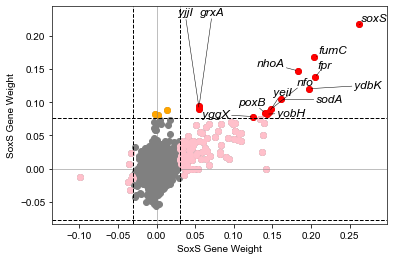

In [14]:
compare_gene_weights(ica_p1k, 'SoxS',
                     'SoxS', ica_data, colors = ['grey'])